<a href="https://colab.research.google.com/github/lidia-notebook/CustomerChurn/blob/main/telecochurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TELECOM CUSTOMER CHURN ANALYSIS** (Supervised)

## **Business Understanding**

In the telecom industry, customer churn—the rate at which subscribers switch to competitors—is a significant threat to growth. Because acquiring a new customer is 6–7 times more expensive than retaining an existing one, prioritizing retention is essential for maintaining revenue.

source: (https://tridenstechnology.com/telecom-churn/)

## **Problem Statement**

Customer churn represents a major challenge for companies, because losong customers directly impacts the company revenue and market competitiveness. Having a. large amounts of customer data doesn't determine which customers are likely to discontinue their services.

Because of that identigying customer who are at risk of churning before they leave is critical for improving customer retention.

## **Project Goals**

### Business Goals
The business objectives of this projects are:
* Reduce customer churn by identifying high-risk customers early.
* Improve marketing and customer service decision-making

### Analytical Goals
* Explore customer tdata to udnerstand behavioral patterns associated with churn
* Identify key variables that influence hurn

### Expected Impact
* Enable early identification of customers likely to churn
* Support targeted retention campaigns for high-risk customers
* Improve resource allocation in marketing and customer support teams

## **Analytical Approach**
This project applies **supervised machine learning** techniques to predict customer churcn using historical customer data.

## **Metrics and Evaluation**
1. **Accuracy** : measures the proportion of correct predictions made by the model.
2. **Precision**: measures the proprotion of predicted churn cases that are actually churn
3. **Recall**: measures the proportion of actual churn customers that the model correctly identifies
4. **F1 Score:** mean of precision and recall and provides a balanced measure when dealing with imabalanced datasets.
5. **ROC-AUC** : it helps to measure model ability to distinguish between churn and non-churn customers.

| Prediction | Actual                             | Meaning                                       |
| ---------- | ---------------------------------- | --------------------------------------------- |
| **TP**     | Predicted churn & actually churn   | We correctly detect a customer who will leave |
| **TN**     | Predicted stay & actually stay     | Customer stays and we predicted correctly     |
| **FP**     | Predicted churn but customer stays | We gave retention incentive unnecessarily     |
| **FN**     | Predicted stay but customer churns | We lost a customer without intervention       |


In short, our focus is **False Negative**

In [108]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE

from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix


# model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### Data Understanding

| Attribute | Description |
|-----------|-------------|
| **customerID** | Unique identifier for each customer |
| **gender** | Gender of the customer (Male/Female) |
| **SeniorCitizen** | Indicates whether the customer is a senior citizen (1 = Yes, 0 = No) |
| **Partner** | Whether the customer has a partner (Yes/No) |
| **Dependents** | Whether the customer has dependents (Yes/No) |
| **tenure** | Number of months the customer has stayed with the company |
| **PhoneService** | Whether the customer has a phone service subscription |
| **MultipleLines** | Whether the customer has multiple phone lines |
| **InternetService** | Type of internet service (DSL, Fiber optic, No) |
| **OnlineSecurity** | Whether the customer has online security service |
| **OnlineBackup** | Whether the customer has online backup |
| **DeviceProtection** | Whether the customer has device protection |
| **TechSupport** | Whether the customer has technical support |
| **StreamingTV** | Whether the customer has streaming TV |
| **StreamingMovies** | Whether the customer has streaming movies |
| **Contract** | Type of contract (Month-to-month, One year, Two year) |
| **PaperlessBilling** | Whether the customer uses paperless billing |
| **PaymentMethod** | Customer's payment method |
| **MonthlyCharges** | The monthly amount charged to the customer |
| **TotalCharges** | The total amount charged to the customer |
| **Churn** | Target variable indicating whether the customer churned (Yes/No) |

### Target Variable

| Variable | Description |
|----------|-------------|
| Churn | Indicates whether the customer left the company (Yes = churned, No = stayed) |

### Feature Categories

The dataset features can be grouped into several categories:

| Category | Variables |
|---------|-----------|
| Customer Demographics | gender, SeniorCitizen, Partner, Dependents |
| Customer Account Information | tenure, Contract, PaperlessBilling, PaymentMethod |
| Services Subscribed | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Financial Information | MonthlyCharges, TotalCharges |
| Target Variable | Churn |

### Analytical Goal

The goal of this analysis is to build a machine learning model that can **predict whether a customer will churn or not** based on their demographic characteristics, subscribed services, and billing information.

This predictive model can help the company:

- Identify customers at high risk of churn
- Improve customer retention strategies
- Reduce revenue loss due to customer churn

# 1. Load Dataset

In [50]:
!pip install -q gdown

In [51]:
!pip install  gdown
import gdown

In [52]:
file_id = "1aiwHoEVRJd4ReWdlXEdTxKL0SlF_1fml"
out_path = "TelcoChurn.csv"

gdown.download(id=file_id, output=out_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1aiwHoEVRJd4ReWdlXEdTxKL0SlF_1fml
To: /content/TelcoChurn.csv
100%|██████████| 978k/978k [00:00<00:00, 40.6MB/s]


'TelcoChurn.csv'

In [53]:
df = pd.read_csv("TelcoChurn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **2. Data Inspection**

In [54]:
df.shape

(7043, 21)

This means the dataset containts **7043 customer records and 21 variables** representing customer demographic, information, services subscribed, billing information and churn status.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [57]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [58]:
df.duplicated().sum()

np.int64(0)

Both missing values or duplicated values are not present on this dataset so we can move on to the next stage, EDA.

# **3. EDA**

The purpose of this phase is to help us to understand patterns, relationships, and potential predictors of churn.

### **3.1 Univariate Analysis**
- Distribution of each feature
- Customer demographic patterns
- Service subscription patterns

### 3.1.1 Target Variable (Churn)

In [59]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


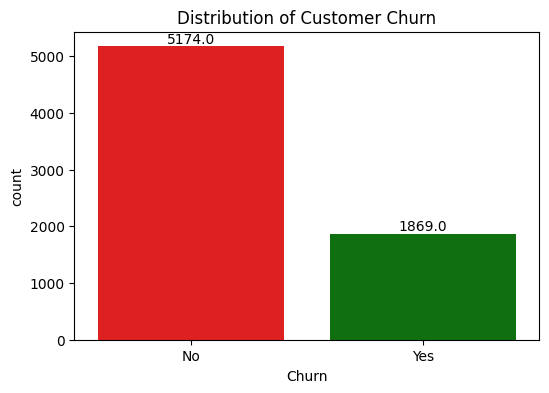

In [60]:
# this of visualization so we can see more clearly
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='Churn',
    palette={'No':'red', 'Yes':'green'}
)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of Customer Churn')
plt.show()

From the data above, we can see the **73.46%** of customers **did not churn** while the other **26.54%** are. Means;
* Most customers are **retained by the company**, but about **1 out of 4 customerbs leave the service**.
* The dataset shows a **moderate class imbalance**, where the "**No Churn" class is dominant**.
* This imbalance should be considered later when **evaluating model performance**, especially when focusing on metrics like **Recall, Precision, and F1-score**, not just accuracy.

### 3.1.2 Numerical variabels

We are going to analyze the distribution of numerical features in the dataset. By understanding these distributions helps identify patterns, skewness, and potential outliers.

The numerical variables analuzed are:
- tenure
- MonthlyCharges
- TotalCharges

In [61]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


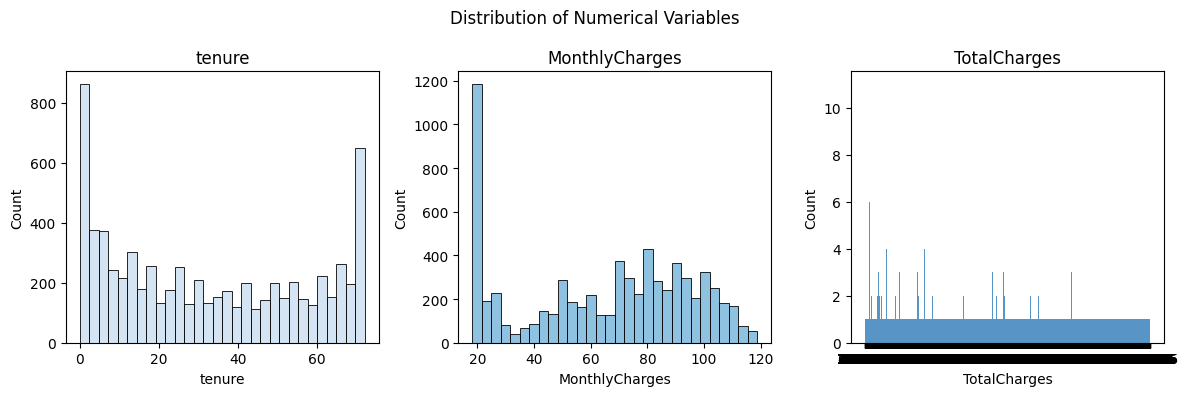

In [38]:
colors = sns.color_palette("Blues", 3)

plt.figure(figsize=(12,4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], bins=30, color=colors[i])
    plt.title(col)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:**

**`Tenure`**
- The distribution shows many customers with **very shower tenure (0-10 months)** and another concetration around **long tenure (around 70monts)
- This suggests the company has **two main customer groupws: new customers and long-term loyal customers.**
- Mid-tenure, customers are relatively more spread out.

**`MonthlyCharges`**
* Monthly charges range roughly between **$20 and $120**
* Most customers pay around **$70-$100** per month, indicating that many customers subscribe to higher price packages.
* While, smaller group pays lower charges which between $20-$40, which most likely the customers with the basic service plans.

**`TotalCharges`**
* The data distribution is **highly right-skewed**, which means most customers have **lower total accumulated charges**, while a smaller number have very high total charges.
* This pattern occus because `TotalCharges` is **influenced by** **tenure**, means customers who stay longer accumulate larger total payments.

**In short,**
* **`Tenure `and `TotalCharges` are likely strongly related.**
* Customer with **low tenure and low total charges may represent new customers**, who could potentially have a **higher churn risk**.


### 3.1.3 Categorical Variables
Still univariate, but analyzing the **distribution of categorical features** to understand customer characteristics.

The goal is to see:
1. which categories are **dominant**
* how customers are **distributed across services**
* possible **business patterns**

In [39]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']


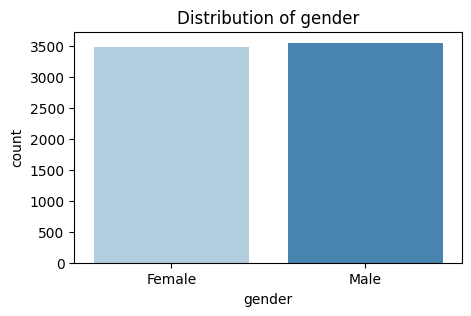

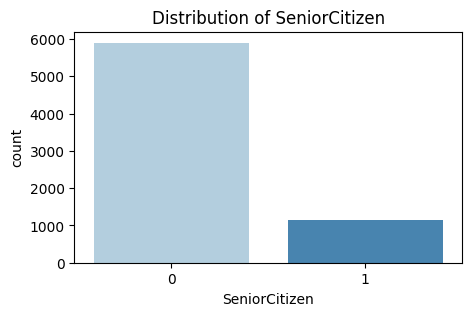

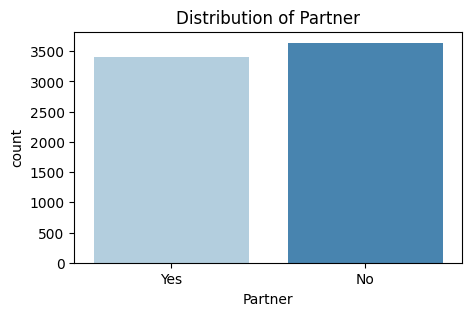

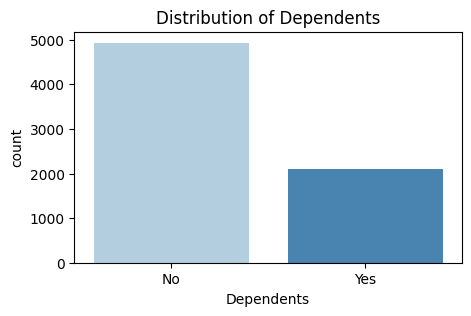

In [40]:
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col, palette="Blues")
    plt.title(f"Distribution of {col}")
    plt.show()

**Interpretations**


`Gender`
* The dataset shows a **balanced distribution** between male and female customers.
* This indicates that the telecom service is **equally used by both genders,** suggesting gender is **unlikely to be a strong differentiator in customer behavior/churn.**
* Marketing and retention strategies therefore **no need to heavily segment by gender.**

`Senior Citizen`
* The majority of the customers are **non-senior citizens (84%), while **senior citizens become the minority (16%)**
* This means, company's customer base is **primarily composed of younger or productive age individuals.**
* Senior citizens may represents a **niche segment with potentially different service needs**, such as simplified billing or customer support.

`Partner`
* The distribution between customers **with a partner and without a partner is relatively balanced**, though slightly more customers **do not have a partner**.
* Customers with partners may represents **more stable households,** which could influence their long-term service commitment.

`Dependents`
* Most customers **do not have dependents**, whila a smaller portion have dependets.
* Customers with dependents may represent **family households**, which could influence service usage such as **internet services, streaming, or bundled packages**.



### 3.1.3.2 Categorical Variables: Service Feature Distribution

This section analyzes the distribution of telecom services subscribed by customers.  
Understanding these services helps identify which products are commonly used and may later influence churn behavior.

In [41]:
service_cols = [
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies'
]

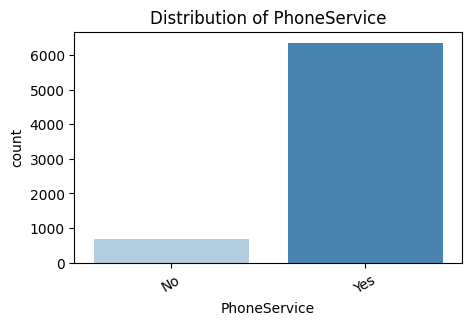

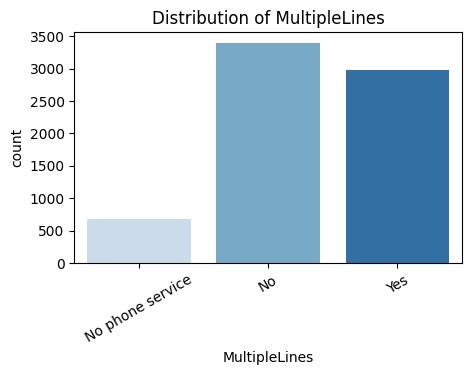

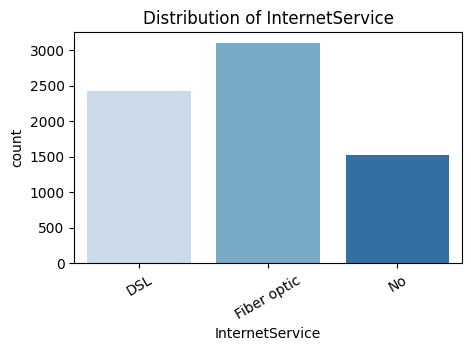

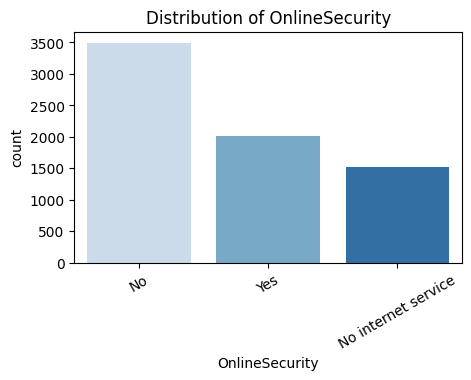

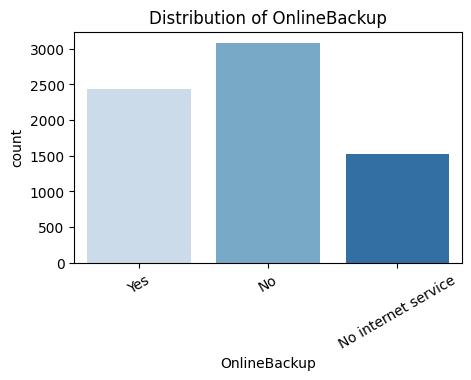

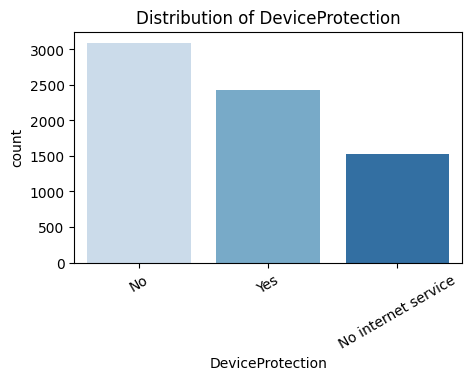

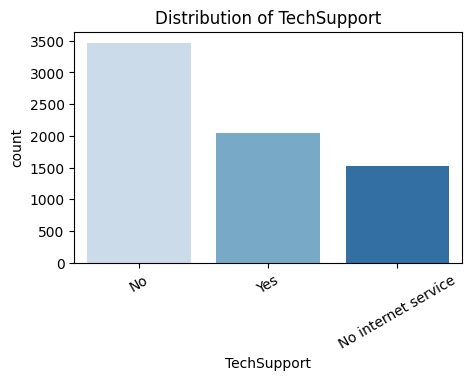

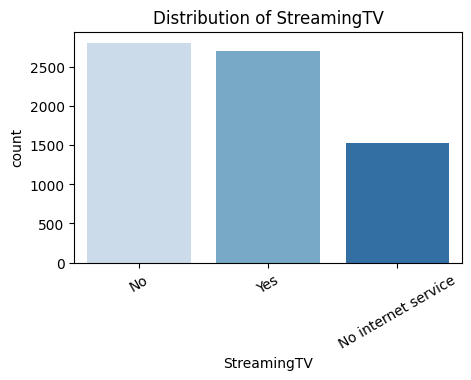

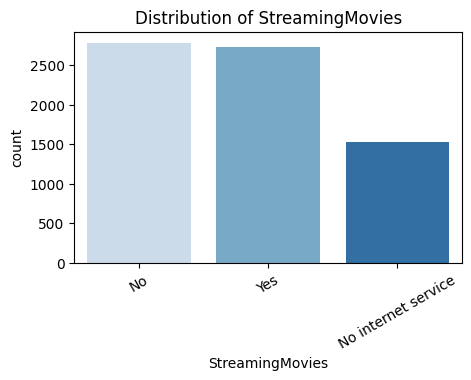

In [42]:
for col in service_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col, palette="Blues")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()

`PhoneService`
* Most customers **subscribe to phone service** meaning it is a **core telecom product**.
* Only a small portion of customers **do not use phone services**, suggesting phone service is **almost a default offering.**

`MultipleLines`
* Majority of customer **do not use multiple lines**, while a slightly smaller group **does use multiple lines.**
* This suggests **multi-line services exist but are not the dominant plan**, possibly used by families or businesses.

`InterenetService`
* **Fiber optic is the most common internet service**, followed by DSL>
* A smaller group **does not subscribe to internet service**, meaning internet services are **a major revenue driver for the company.**

`OnlineSecurity`
* Most custoner **not subcribe to online security services**
* This suggests **low adoption of security add-ons**, which could represent an **upselling opportunity** for the company.

`OnlineBackup`
* More customer **not use online backup services** than those who do.
* this indicates **additional digital protection services are underutilized**, offering potential for **service bundling strategies**.

`DeviceProtection`
* The majority of customers **not subsrive to device protenctions**
* Means customers may **not perceive high value in device protection services**, or the company has **limited promotion of this add on.**

`TechSupport`
* Most customers **do not have technical support services**.
* This could indicate **low adoption of premium support packages**, which may affect **customer satisfaction and churn risk.**

`StreamingTV`
* The number of customers **with and without streaming TV is relatively balanced**.
* Means, streaming TV is **a moderately popular entertainment add-on.**

**Overall Business Insight:**
* **Core services:** phone service and internet service are wifely adopted.
* **Add-on services:** security, backup, protection, and support have **lower adoption** indicating **potential upsell oppurunities**
* **Entertainment services:** streaming TV and movies show **moderate adoption**, suggesting entertainment bundles could influence customer engagement.

### **3.2 Bivariate Analysis**
- Relationship between features and churn
- Churn distribution across customer segments

### 3.2.1 Churn vs Demographic Features

This analysis examines the relationship between customer demographic characteristics and churn behavior.

In [43]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']


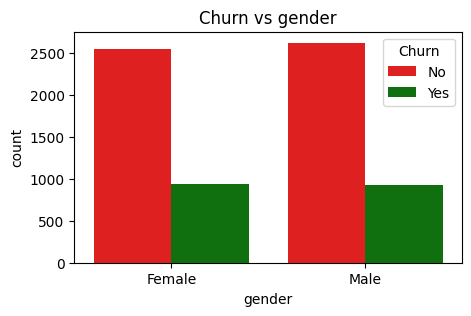

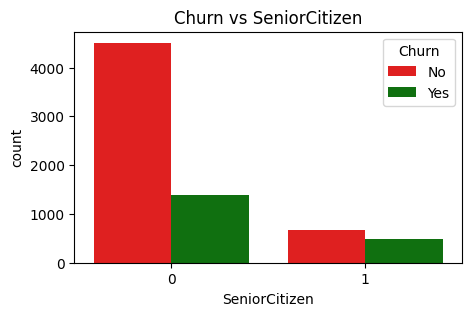

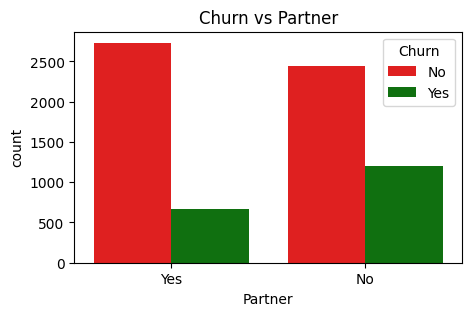

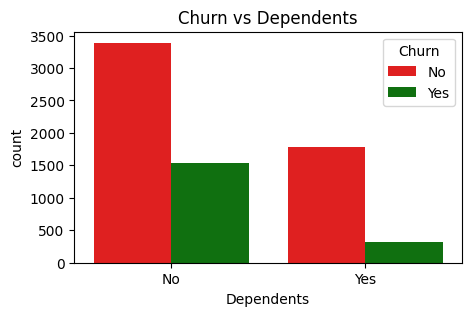

In [44]:
for col in demo_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col, hue='Churn', palette={'No':'red','Yes':'green'})
    plt.title(f"Churn vs {col}")
    plt.show()

**Interpretations:**

`Gender` vs `Churn`
Churn behavior appears **similar between male and female customers**, suggesting **gender is not a strong factor influencing churn.**

`SeniorCitizen` vs `Churn`
Sennior citizen show a **higher proportion of churn** compared to non-senior customers, suggesting this segment **may require better support or tailored services**.

`Partner` vs `Churn`
Customers **without a partner churn more frequently** than those with a apartner, indicating that **single customers may be less stable subscribers.**

`Depedents` vs `Churn`
Customers **without dependets show higher churn**, while those with dependets tend to **stay longer**, suggesting family households may have **more stable service usage.**

### 3.2.2 `Churn` vs Services

The target that we are going to analyze to know **what the biggest churn drivers are:**
* `InternetService`
* `OnlineSecurity`
* `TechSupport`
* `StreamingTV`
* `StreamingMovies`

In [45]:
service_cols = [
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies'
]


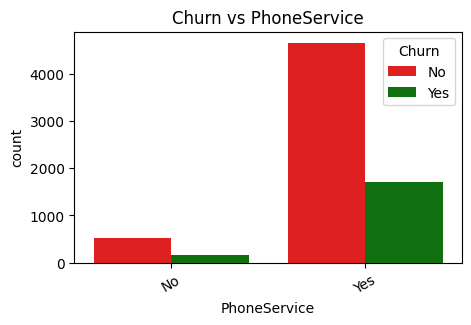

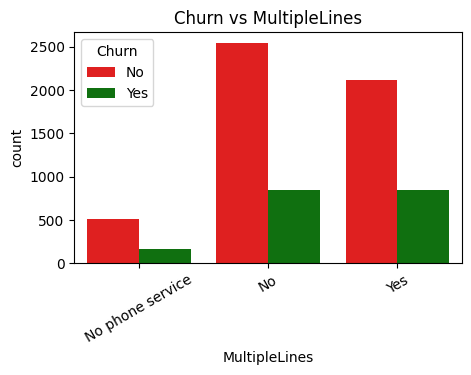

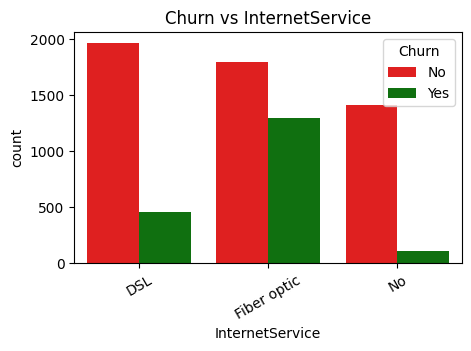

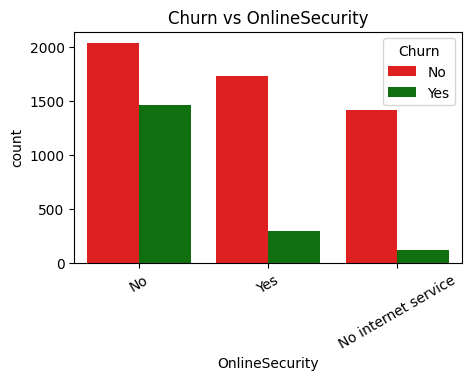

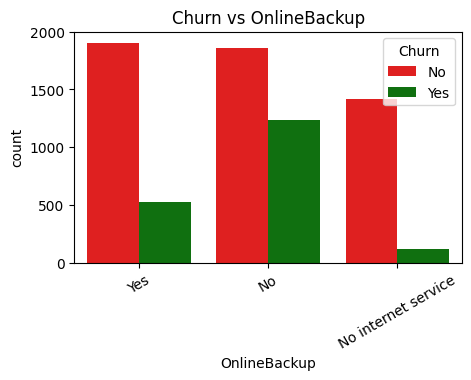

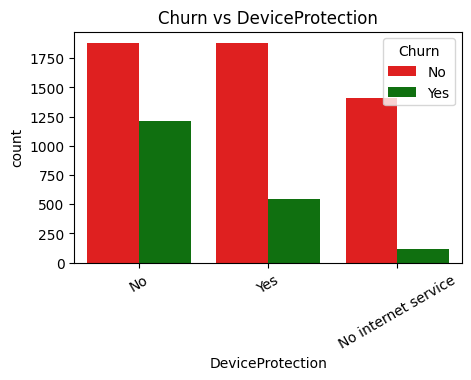

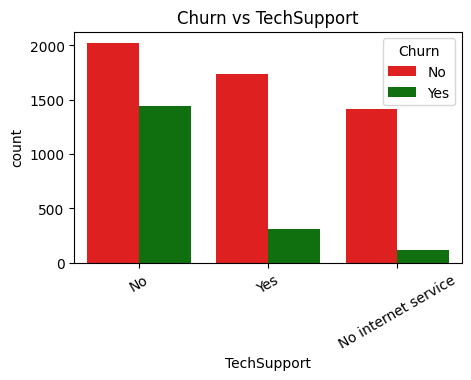

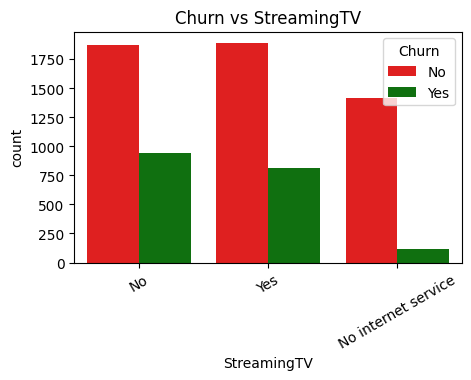

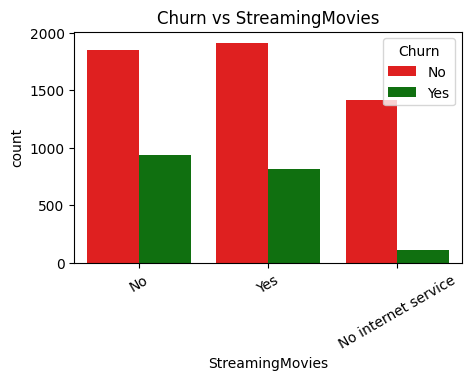

In [46]:
for col in service_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col, hue='Churn', palette={'No':'red','Yes':'green'})
    plt.title(f"Churn vs {col}")
    plt.xticks(rotation=30)
    plt.show()

**Insights**

**`PhoneService`**

Churn patterns are similar for customers with and without phone service, indicating phone service alone is **not. a strong driver of churn**
**recommendation:** focus retention strategies more on **internet-related services rather than phone services.**

**`MultipleLines`**

Customers with or without multiple lines show **similar churn patterns**, suggesting multiple lines are **not a major churn factor**
**recommendation:** multiple line packages can be **bundled with other services** to increase perceived value.

**`InternetService`**

Customers with **fiber optic internet show the highest churn**, indicating potential dissastifaction with this service.
**recommendation:** improve **fiber optic service quality, pricing, or customer support**, as this segment appears to be at **higher churn risk**.

**`OnlineSecurity`**

Customers **without online security show significantly higher churn** comapred to those who subscribe.
**recommendation:** encourage customers to **add security services**, as these customers appear more likely to stay.

**`OnlineBackup`**

customers without online backup show **higher churn**, suggesting that customers using additional services are more engaged.
**recommendation:** promote **backup services as part of bundled packages** to increase customer retention.

**`DeviceProtection`**

Customers without device protection have **higher churn**, indicating that **customers with additional protection services tend to stay longer.**
**recommendation:** offer **discounted protection add-ons** to increase customer stickiness.

**`TechSupport**

Customers without technical support show **much higher churn**, making this one of the **strongest churn indicators.**
**recommendation: promote **tech support packages** and improve support accessibility to reduce churn.

**`StreamingTV`**

Customers with and without streaming TV show **relatively balanced churn**, suggesting moderate impact on churn behavior.
**recommendation:** streaming services can be used as **valued-added entertainment bundles**.

**`StreamingMovies`**

Churn behavior is relatively similar across streaming movie subscribers and non-subscribers.
**recommendation:** streaming services may be used to **increase customer satisfaction rather than directly reduce churn.**

### 3.2.3 `Churn` vs Contract & Billing

This analysis examines how customer contract types and billing methods relate to churn behavior. It's important because billing structure and contract commitment often influence customer retention.

In [47]:
billing_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

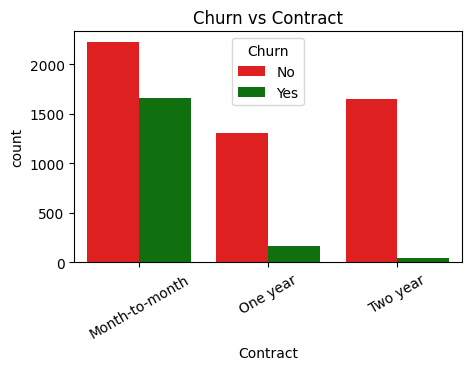

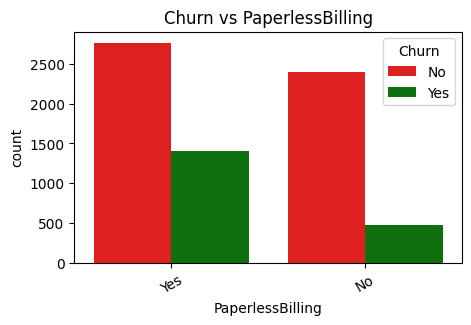

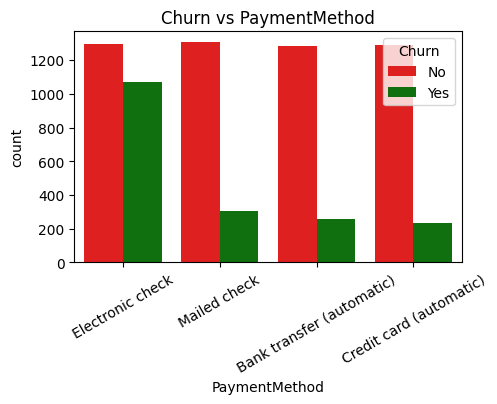

In [48]:
for col in billing_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col, hue='Churn', palette={'No':'red','Yes':'green'})
    plt.title(f"Churn vs {col}")
    plt.xticks(rotation=30)
    plt.show()

**Insight**

**`Contract` vs `Churn`**

Customers with **month-to-month contracts show significantly higher churn**, while **long-term contractts(1-2 years) have very low churn.**
**recommendation:** encourage customers to **switch to longer-term contracts** through discounts, loyalty programs, or budnled services.

** `PaperlessBilling` vs `Churn`**

Customers using **paperless billing show higher churn** compared to those using traditional billing.
**recommendation:** investigae whether **paperless billing customers are more price-sensitive or digital-first users,** and offer **targeted retention offers.**

**`PaymentMethod` vs `Churn`**

Customers using **electronic check show the highest churn**, while **automatic payments (bank transfer or credit card) showe lower churn.**
**recommendation:** encourage customers to switch to **automatic payment methods**, which may increase convenience and reduce churn.

**Key Business Takeaway**

The strongest churn indicators appear to be:
* Month-to-month contracts
* Electronic check payment
* Fiber optic internet
* Lack of TechSupport / Security services.

### **3.3 Multivariate Analysis**
- Interaction between multiple variables
- Identificatin of strong churn indicators.

This phase is used to examines the relationships between multiple numerical variables using a correlation matrix. Understanding these relationships helps identify potential dependencies between variables that may influence churn prediction models.

In [63]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

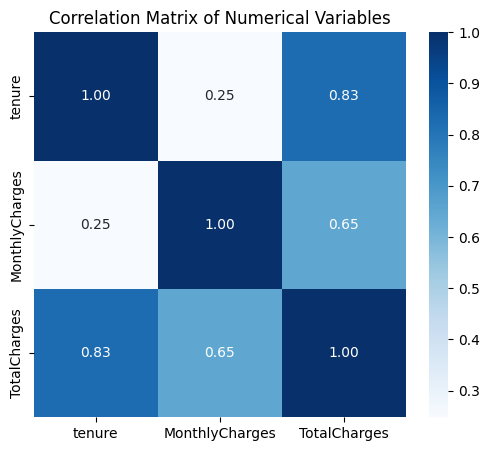

In [64]:
plt.figure(figsize=(6,5))

corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

**Interpretations:**

**`Tenure` vs `TotalCharges`(0.83 - strong positive correlation)***

Customers who stay longer with the company accumulate **higher total charges**, which is expected because they continue paying monthly over time. This indicates that **long-term customers contribute more revenue to the company.**

**`MonthlyCharges` vs `TotalCharges` (0.65 - Moderate Positive Correlation)**

Customers who pay **higher monthly fees tend to accumulate higher total spending** over time. This indicates that customers with **premium service plans generate higher lifetime value.**

**`Tenure` vs `MonthlyCharges` (0.25 - Weak Correlation)**

Monthly charges are **not strongly related to how long customers stay.** This means both **low-cost and high-cost plans can retain customers**, depending on other factors such as service quality or contract type.

**Business Insight**
1. **Long term customers generate the highest revenue** for the company.
2. Retaining customers for longer period is **more valuable than simply increasing monthly charges**.

**Strategies recommendations** for company to gain customer retantion could be;
* Encouraging customers to **stay longer through long-term contracts**
* Offering **loyalty reward long-tenure customers**
* Providing **budnled services** that increase customer lifetime value.

# **4. Train-Test Split**



The dataset will be divided into two subsets: a training dataset and a testing dataset. This step is essential in machine learning to evaluate how well a model can generalize to new, unseen data.

The training dataset is used to train the machine learning models and learn patterns from the data. The testing dataset, on the other hand, is kept separate and is only used to evaluate the final performance of the trained models.

By separating the dataset in this way, we can simulate how the model will perform when applied to real-world data. This helps prevent overfitting, where a model performs well on training data but poorly on new data.

In this project, the dataset will be split into:
- **80% training data**
- **20% testing data**

Stratified sampling will also be applied to ensure that the proportion of churned and non-churned customers remains consistent in both training and testing datasets.

After this process, the data will be divided into four components:
- **X_train**: feature variables used for training the model
- **X_test**: feature variables used for evaluating the model
- **y_train**: target variable for training
- **y_test**: target variable for testing

## 4.1 Separate features (`X`) and target (`y`)

* **X** is the predictor variables
* **y** is target variable (`churn`)

In [65]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [66]:
print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


This means **7043 customers** are preserved.

### 4.2 Split Dataset into Training and Testing Sets.
This step divides the dataset into 2 parts:
* **Training set (80%)** used to train the machine learning model.
* **Testing set (20%)** used to evaluate the model on unseen data.

We will also use **stratified sampling** to maintain the same proportion of churn and non-churn customers in both datasets.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5634, 20)
Testing set shape: (1409, 20)


From the data shows we could see that the training and testing set has been divided with 80/20 method.

# **5. Data Preprocessing**

In this phase, the dataset is prepared to ensure it is suitable for machine learning modeling. Raw datasets often contain inconsistencies such as incorrect data types, missing values, or categorical variables that need to be transformed into numerical representations.

Data preprocessing is an important step because machine learning algorithms require clean, structured, and numerical input to perform effectively.

The preprocessing steps that will be performed in this project include:

1. **Data Type Correction**  
   Some variables may have incorrect data types. For example, the `TotalCharges` column needs to be converted into a numeric format so it can be used in analysis and modeling.

2. **Removing Irrelevant Features**  
   Columns that do not contribute to prediction, such as unique identifiers (e.g., `customerID`), will be removed from the dataset.

4. **Encoding Categorical Variables**  
   Since machine learning models require numerical inputs, categorical variables (such as contract type, payment method, and internet service type) will be transformed into numerical representations using encoding techniques.

5. **Feature Preparation**  
   The dataset will be separated into:
   - **Feature variables (X)** — independent variables used to make predictions
   - **Target variable (y)** — the variable to be predicted, which in this case is `Churn`

These preprocessing steps ensure that the dataset is properly structured before splitting the data into training and testing sets and building machine learning models.

### 5.1 Remove irrelvant Feature (`customerID`)

`customerID` is only a unique identifier yet not necessasry for predicting churn. We are going to delete it since it could **add noise to the model.**

In [69]:
X_train = X_train.drop('customerID', axis=1)
X_test = X_test.drop('customerID', axis=1)

In [71]:
print('customerID' in X_train.columns)

False


This shows that 'customerID` has been removed.

### 5.2 Fix `TotalCharges` Data type

During EDA we discovered **is stores as a string**, not a numeric value.

In [72]:
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

In [73]:
# check type
print(X_train['TotalCharges'].dtype)

float64


### 5.3 Encode Categorical variables.

We are going to convert categorical variables into **numerical format** by using **OHE**

In [74]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [75]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### 5.4 Feature Scaling

This feature is important especially for **Logistic Regression** since its sensitive to feature magnitude.

In [79]:
from sklearn.preprocessing import StandardScaler


In [80]:
scaler = StandardScaler()

In [81]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **6. Model Development**

### 6.1 Define Models

In [93]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In this step, we are just creating the models first **without** training them first.

### 6.2 Train the Models

In [95]:
# encode target for XGBoost
y_train_encoded = y_train.map({'No': 0, 'Yes': 1})
y_test_encoded = y_test.map({'No': 0, 'Yes': 1})

# store results
results = {}

In [96]:
# train and evaluate all models
for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train_scaled, y_train_encoded)
        score = model.score(X_test_scaled, y_test_encoded)
    else:
        model.fit(X_train_scaled, y_train)
        score = model.score(X_test_scaled, y_test)

    results[name] = score

# Show results
results

{'Logistic Regression': 0.8069552874378992,
 'Decision Tree': 0.7345635202271115,
 'Random Forest': 0.7892122072391767,
 'XGBoost': 0.7849538679914834}

From the result, we can see
* **LogReg** with **80.7% accuracy**.
* **Random Forest** with **78.9%** accuracy
* **XGBoost** with **73.5%** accuracy
* **DecisionTree** with 73.5%** accuracy

**Note:** accuracy **is not the most important metric for churn prediction** because churn datasets are usually **imabalances**, thats why **F1-score** and **ROC-AUC** also matter. And the **real goal is** **catch as many churn customers as possible before they leave**.

### 6.3 K-Fold Cross Valudation

Here are going to split data into **5 parts**, then we do average the results.

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
cv_results = {}

for name, model in models.items():

    if name == "XGBoost":
        scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    cv_results[name] = scores.mean()

cv_results

{'Logistic Regression': np.float64(0.804044595674396),
 'Decision Tree': np.float64(0.730920045831291),
 'Random Forest': np.float64(0.7898449332625165),
 'XGBoost': np.float64(0.7827439200253428)}

**K-Fold Cross Validation Results**

| Model | Average Accuracy |
|------|------------------|
| Logistic Regression | **80.40%** |
| Random Forest | 78.98% |
| XGBoost | 78.27% |
| Decision Tree | 73.09% |

### Interpretation

Based on the 5-Fold Cross Validation results, **Logistic Regression achieved the highest average accuracy (80.40%)**, indicating it performs the most consistently across different data splits. Random Forest and XGBoost also show strong performance with accuracies close to 79%, suggesting they are reliable alternative models. Meanwhile, Decision Tree produced the lowest accuracy (73.09%), which may indicate overfitting or lower generalization ability compared to ensemble models.

Overall, Logistic Regression appears still the most stable model for predicting customer churn in this dataset.

# **7. Model Evaluation**

Now we are going to model evaluation with more comperhensive metrics such as **accuracy, precision, recall, F1-Score, ROC-AUC**

In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

evaluation_results = []

In [106]:
for name, model in models.items():

    if name == "XGBoost":
        model.fit(X_train_scaled, y_train_encoded)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        y_true = y_test_encoded

    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]

        # convert labels
        y_true = y_test.map({'No':0,'Yes':1})
        y_pred = pd.Series(y_pred).map({'No':0,'Yes':1})

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841582
1,Decision Tree,0.736693,0.504132,0.489305,0.496608,0.657202
2,Random Forest,0.789922,0.629139,0.508021,0.562130,0.824860
3,XGBoost,0.784954,0.607903,0.534759,0.568990,0.821416


**Model Evaluation Result**

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|------|------|------|------|------|------|
| Logistic Regression | 80.70% | 65.84% | 56.68% | 60.92% | **84.16%** |
| Decision Tree | 73.67% | 50.41% | 48.93% | 49.66% | 65.72% |
| Random Forest | 78.99% | 62.91% | 50.80% | 56.21% | 82.49% |
| XGBoost | 78.50% | 60.79% | 53.48% | 56.90% | 82.14% |

### Technical Interpretation

Based on the evaluation metrics, **Logistic Regression achieved the best overall performance**. It produced the highest accuracy (80.7%), the highest recall (56.7%), and the highest F1-score (60.9%), indicating that the model balances precision and recall better than the other algorithms. Additionally, Logistic Regression also achieved the highest ROC-AUC score (0.84), suggesting that it has the strongest ability to distinguish between churn and non-churn customers.

Random Forest and XGBoost performed moderately well, with similar accuracy and ROC-AUC values around 0.82. However, both models have lower recall compared to Logistic Regression, meaning they detect fewer churn customers. Decision Tree shows the weakest performance across almost all metrics, suggesting that a single-tree model is less capable of generalizing the churn patterns within the dataset.

### Business Interpretation

From a business perspective, the most important objective of churn prediction is to **identify as many potential churn customers as possible before they leave**, allowing the company to perform retention actions such as discounts, loyalty programs, or personalized offers.

Among the models, **Logistic Regression provides the highest recall (56.7%)**, meaning it detects the largest proportion of customers who are actually going to churn. This is important because failing to detect churn customers (false negatives) leads to lost revenue when customers leave without intervention.

Although Random Forest and XGBoost have similar overall accuracy, their lower recall means they would miss more churn customers compared to Logistic Regression. Therefore, Logistic Regression is the most suitable model for this churn prediction task because it provides the best balance between predictive performance and business impact.

Overall, using **Logistic Regression** enables the company to **identify more at-risk customers and implement targeted retention strategies**, potentially reducing customer churn and protecting long-term revenue.

# **8. Confusion Metrix**

In [111]:
# convert actual labels
y_true = y_test.map({'No':0,'Yes':1})

# convert predictions safely
y_pred_numeric = pd.Series(y_pred).replace({'No':0,'Yes':1})

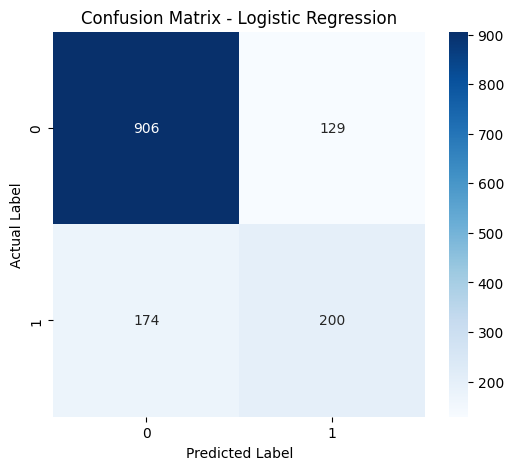

In [112]:
cm = confusion_matrix(y_true, y_pred_numeric)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**Interpretation**

| Actual \ Predicted | Stay (0) | Churn (1) |
|-------------------|----------|-----------|
| Stay (0) | 906 | 129 |
| Churn (1) | 174 | 200 |

### Technical Interpretation

- **True Negative (TN): 906**  
  Customers correctly predicted to stay.

- **False Positive (FP): 129**  
  Customers predicted to churn but actually stayed.

- **False Negative (FN): 174**  
  Customers predicted to stay but actually churned.

- **True Positive (TP): 200**  
  Customers correctly predicted to churn.

The model successfully identified **200 churn customers**, while **174 churn customers were missed** (False Negatives).

This aligns with the earlier recall score (~56.7%), which indicates the model detects a little more than half of actual churn cases.

### Business Interpretation

From a business perspective, the most critical error is **False Negative (174 customers)** because these customers churned without the company being able to intervene. Each missed churn customer represents potential lost revenue and customer lifetime value.

However, the model correctly identifies **200 customers who are likely to churn**, allowing the company to take proactive retention actions such as offering discounts, loyalty incentives, or personalized service improvements.

The **129 False Positives** represent customers who were predicted to churn but actually stayed. While this may lead to unnecessary retention offers, the cost of such incentives is typically much lower than the revenue lost from churn customers.

Overall, the model provides a useful tool for **early churn detection**, enabling the company to focus retention efforts on high-risk customers and potentially reduce customer attrition.

# **9. Business Insights**

### 9.1 Key Churn Drivers

Based on exploratory data analysis and model evaluation, several factors appear to influence customer churn.

**Contract Type**

Customers with **month-to-month contracts show significantly higher churn rates** compared to customers with one-year or two-year contracts. This suggests that customers without long-term commitment are more likely to switch providers.

**Service Support Features**

Customers who **do not subscribe to additional services such as online security, online backup, or technical support** tend to have higher churn risk. These services may increase perceived value and customer satisfaction.

**Internet Service Type**

Customers using **fiber optic internet show higher churn rates** compared to DSL users. This could indicate higher expectations from premium services or potential dissatisfaction with pricing or service quality.

**Monthly Charges**

Customers with **higher monthly charges tend to churn more frequently**, suggesting that pricing sensitivity plays an important role in churn behavior.

---

### 9.2 Business Recommendations

Based on the churn drivers identified, the following strategies could help reduce customer churn.

| Identified Insight | Recommended Action |
|-------------------|-------------------|
| Month-to-month customers churn more frequently | Offer incentives or discounts for longer-term contracts |
| Customers without tech support show higher churn risk | Bundle technical support services with internet plans |
| Higher monthly charges increase churn likelihood | Introduce loyalty discounts or tiered pricing plans |
| Fiber optic customers show higher churn | Improve service reliability and customer support |

These strategies allow the company to **proactively retain customers and improve long-term customer satisfaction**.

---

### 9.3 Potential Business Impact

The churn prediction model enables the company to **identify customers at high risk of leaving**, allowing targeted retention strategies before churn occurs.

Assuming:

- Average monthly revenue per customer = **$50**
- Customers correctly predicted as churn (True Positives) = **200 customers**

If the company successfully retains **30% of these at-risk customers** through targeted retention programs:

Customers retained:

200 x 30% = 60 customers

**Potential annual revenue protected:** 60 x $50 x 12months = $36000


This demonstrates that implementing a churn prediction model can **directly contribute to revenue protection and improved customer lifetime value**.


In [113]:
import joblib

joblib.dump(final_model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']